Libraries used

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

understanding data

In [16]:

data = pd.read_csv("customer_segmentation.csv")
df = data.copy()

df['Income'] = df['Income'].fillna(df['Income'].median())

df['Age'] = 2014 - df['Year_Birth']
df['TotalSpend'] = (df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + 
                    df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds'])
df['TotalKids'] = df['Kidhome'] + df['Teenhome']




data scaling

In [9]:

X = df[['Income', 'TotalSpend']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

finding the optimal k value

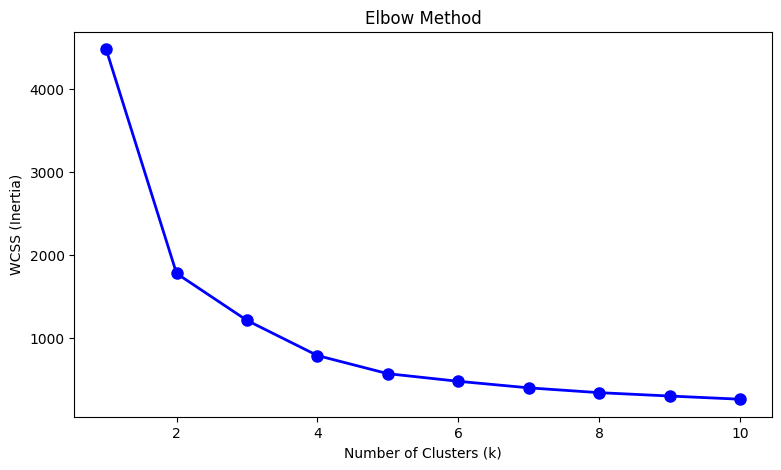

In [10]:

wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), wcss, 'bo-', linewidth=2, markersize=8)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.show()

Score Validation

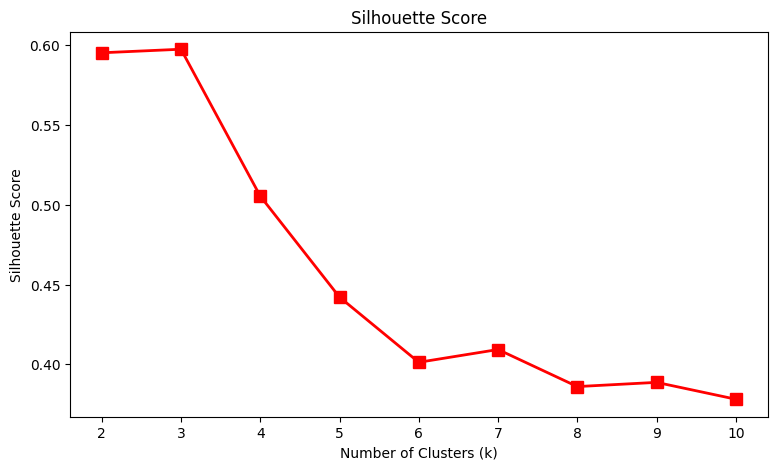

Best k: 3 (score = 0.5974)


In [11]:

sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(9, 5))
plt.plot(range(2, 11), sil_scores, 'rs-', linewidth=2, markersize=8)
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

print(f"Best k: {range(2,11)[sil_scores.index(max(sil_scores))]} (score = {max(sil_scores):.4f})")

Training model

In [12]:

kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df['Cluster'].value_counts().sort_index())

Cluster
0    631
1    357
2    691
3      1
4    560
Name: count, dtype: int64


Visualizing clusters

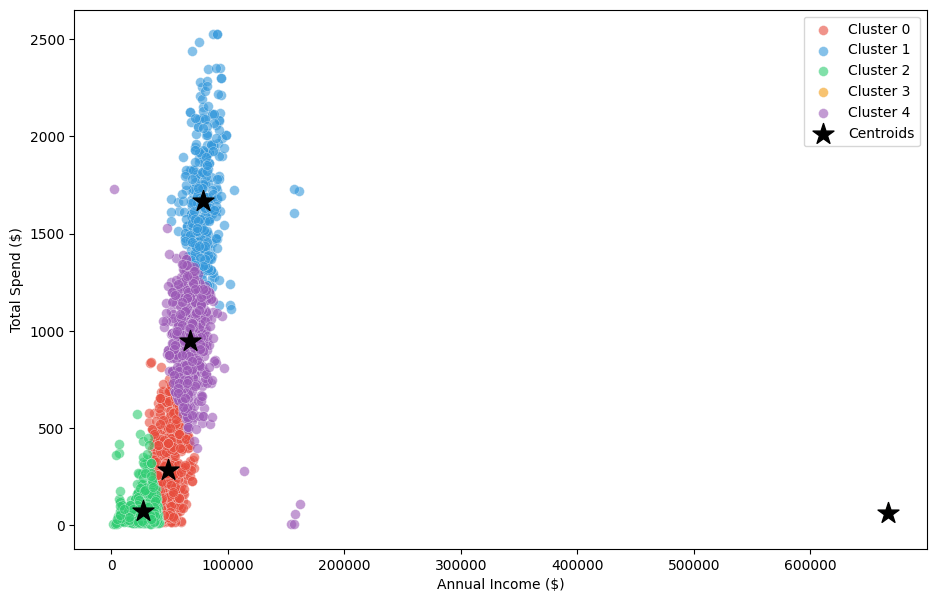

In [13]:

centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(11, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for cluster_id in range(5):
    mask = df['Cluster'] == cluster_id
    plt.scatter(df.loc[mask, 'Income'], df.loc[mask, 'TotalSpend'],
                s=50, alpha=0.6, color=colors[cluster_id],
                label=f'Cluster {cluster_id}', edgecolors='white', linewidths=0.3)

plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            s=250, marker='*', color='black', zorder=5, label='Centroids')
plt.xlabel('Annual Income ($)')
plt.ylabel('Total Spend ($)')
plt.legend()
plt.show()

In [14]:

profile_cols = ['Income', 'TotalSpend', 'Age', 'TotalKids', 'Recency',
                'NumWebPurchases', 'NumStorePurchases']
cluster_profile = df.groupby('Cluster')[profile_cols].mean().round(1)
print(cluster_profile)

           Income  TotalSpend   Age  TotalKids  Recency  NumWebPurchases  \
Cluster                                                                    
0         49213.9       287.1  47.1        1.3     49.2              4.0   
1         79209.7      1668.4  45.9        0.3     50.3              5.5   
2         27731.2        71.3  40.8        1.1     48.8              1.9   
3        666666.0        62.0  37.0        1.0     23.0              3.0   
4         67593.4       947.9  48.0        0.7     48.8              5.9   

         NumStorePurchases  
Cluster                     
0                      4.9  
1                      8.3  
2                      2.9  
3                      3.0  
4                      8.7  


Income distribution by cluster

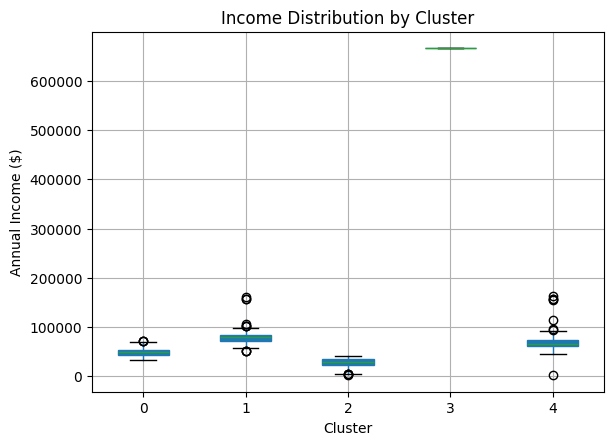

In [15]:

df.boxplot(column='Income', by='Cluster', patch_artist=True)
plt.suptitle('')
plt.title('Income Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Annual Income ($)')
plt.show()